#SQLによるデータ管理

##　目的
- 株価データをSQLite データベースに保存する。
- SQLでデータの集計・加工を行う
- PythonとSQLを連携させてデータ分析に活用する

##なぜ SQLを使うのか
- 実務ではデータはデータベースに保存されている。
- 「データ取得→加工→分析」の流れを再現

## SQLiteとは
-ファイル一つで動く軽量データベース


In [1]:
#ライブラリのインポート
import sqlite3
import pandas as pd
import yfinance as yf
from datetime import datetime

print("✓ ライブラリのインポート完了")
print(f" SQLite バージョン: {sqlite3.sqlite_version}")

✓ ライブラリのインポート完了
 SQLite バージョン: 3.49.1


## 1.データベース作成 + テーブル設計

###テーブル構成
- **raw_nikkei225**:yfinanceから取得した生データをそのまま保存
- **processed_monthly**:月次で集計したデータ

###設計の考え方
「生データ」と「加工済みデータ」を分けるのは実務の基本。
生データは変更せず保管し、加工は別テーブルで行う。

In [2]:
# 1. SQLite に接続 (ファイルがなければ自動作成)
conn = sqlite3.connect('nikkei225.db')
cursor = conn.cursor()

print("✓　データベース接続完了: nikkei225.db")

# 2. Rawテーブル作成
cursor.execute("""
    CREATE TABLE IF NOT EXISTS raw_nikkei225 (
               date TEXT PRIMARY KEY,
               open REAL,
               high REAL,
               low REAL,
               close REAL,
               volume INTEGER
               )
""")
conn.commit()

print("✓ raw_nikkei225 テーブル作成完了")

#テーブル情報を確認
cursor.execute("PRAGMA table_info(raw_nikkei225)")
columns = cursor.fetchall()
print("\n【テーブル構造】")
for col in columns:
    print(f" {col[1]:>10} | {col[2]}")

✓　データベース接続完了: nikkei225.db
✓ raw_nikkei225 テーブル作成完了

【テーブル構造】
       date | TEXT
       open | REAL
       high | REAL
        low | REAL
      close | REAL
     volume | INTEGER


## 2.データのINSERT (挿入)
yfinance で取得したデータをSQLテーブルに保存する。

In [3]:
# yfinanceからデータ取得
nikkei = yf.download('^N225', start='2019-01-01')
nikkei.columns = nikkei.columns.get_level_values(0)

# pandas → SQLite に INSERT
# dataをインデックスから列に変換
nikkei_for_sql = nikkei[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
nikkei_for_sql.index = nikkei_for_sql.index.strftime('%Y-%m-%d')
nikkei_for_sql.index.name = 'date'

# to_sql で一括 INSERT
nikkei_for_sql.to_sql('raw_nikkei225', conn, if_exists='replace')

#件数を確認
count = pd.read_sql("SELECT COUNT(*) as cnt FROM raw_nikkei225", conn)
print(f"✓ raw_nikkei225に {count['cnt'][0]}行をINSERT完了")

#最初の5行をSQLで取得して確認
sample = pd.read_sql("SELECT * FROM raw_nikkei225 LIMIT 5", conn)
print("\n　【最初の5行(SQLで取得)】")
print(sample)

[*********************100%***********************]  1 of 1 completed

✓ raw_nikkei225に 1766行をINSERT完了

　【最初の5行(SQLで取得)】
         date          Open          High           Low         Close  \
0  2019-01-04  19655.130859  19692.580078  19241.369141  19561.960938   
1  2019-01-07  19944.609375  20266.220703  19920.800781  20038.970703   
2  2019-01-08  20224.669922  20347.919922  20106.359375  20204.039062   
3  2019-01-09  20366.300781  20494.349609  20331.199219  20427.060547   
4  2019-01-10  20270.880859  20345.919922  20101.929688  20163.800781   

     Volume  
0  91600000  
1  81500000  
2  86400000  
3  72800000  
4  73700000  


##3. SQLでの基本的なクエリ(データ取得・絞り込み・集計)

SQLの基本構文:
'''sql
SELECT 列名  　　　--何を取得するか
FROM テーブル名　　--どのテーブルから
WHERE 条件        --どの行を(絞り込み)
GROUP BY 列名     --どう分類するか
ORDER BY 列名     --どう並べるか
LIMIT 件数        --何件まで

In [4]:
# クエリ 1:特定期間のデータを取得
print("【クエリ１】2024年のデータ(最初の5行)")
q1 = pd.read_sql("""
                 SELECT date, close, volume
                 FROM raw_nikkei225
                 WHERE date BETWEEN '2024-01-01' AND '2024-12-31'
                 ORDER BY date
                 LIMIT 5
""", conn)
print(q1)

# クエリ2: 終値が40000円以上の日を数える
print("\n 【クエリ2】終値 40,000円以上の日数")
q2 = pd.read_sql("""
                 SELECT COUNT(*) as days_above_40000
                 FROM raw_nikkei225
                 WHERE close >= 40000
""", conn)
print(q2)

#クエリ３: 年ごとの平均終値
print("\n 【クエリ３】年ごとの平均終値")
q3 = pd.read_sql("""
                 SELECT
                    SUBSTR(date, 1,4) as year,
                    ROUND(AVG(close), 2) as avg_close,
                    ROUND(MAX(close), 2) as max_close,
                    ROUND(MIN(close), 2) as min_close,
                    COUNT(*) as trading_days
                 FROM raw_nikkei225
                 GROUP BY SUBSTR(date, 1, 4)
                 ORDER BY year
""", conn)
print(q3)

【クエリ１】2024年のデータ(最初の5行)
         date         Close     Volume
0  2024-01-04  33288.289062  117300000
1  2024-01-05  33377.421875  115300000
2  2024-01-09  33763.179688  112100000
3  2024-01-10  34441.718750  106000000
4  2024-01-11  35049.859375  130100000

 【クエリ2】終値 40,000円以上の日数
   days_above_40000
0               197

 【クエリ３】年ごとの平均終値
   year  avg_close  max_close  min_close  trading_days
0  2019   21697.23   24066.12   19561.96           241
1  2020   22703.03   27568.15   16552.83           242
2  2021   28836.54   30670.10   27013.25           245
3  2022   27257.79   29332.16   24717.53           244
4  2023   30716.56   33753.33   25716.86           246
5  2024   38396.74   42224.02   31458.42           245
6  2025   41794.15   52411.34   31136.58           243
7  2026   54409.93   58850.27   51063.72            60


##4. 月次集計テーブルの作成(processed_monthly)
SQLで月ごとの統計データを集計し、新しいテーブルに保存する。

これが「ＥＴＬのＴ(transform)」にあたる処理。
生データ(raw)→加工データ(processed)という流れ。

In [5]:
#月次集計テーブルを作成
cursor.execute("DROP TABLE IF EXISTS processed_monthly")

cursor.execute("""
               CREATE TABLE processed_monthly AS
               SELECT
                    SUBSTR(date, 1, 7) as month,
                    ROUND(AVG(close), 2) as avg_close,
                    ROUND(MAX(close), 2) as max_close,
                    ROUND(MIN(close), 2 ) as min_close,
                    COUNT(*) as trading_days,
                    ROUND((MAX(close) - MIN(close)) / MIN(close) * 100, 2) as price_range_pct
               FROM raw_nikkei225
               GROUP BY SUBSTR(date, 1, 7)
               ORDER BY month
""")
conn.commit()

#結果を確認
monthly = pd.read_sql("SELECT * FROM processed_monthly", conn)
print(f"✓ processed_monthly テーブル作成完了: {len(monthly)}ヶ月分")
print(f"\n 【最新12か月のデータ】")
print(monthly.tail(12).to_string(index=False))

✓ processed_monthly テーブル作成完了: 88ヶ月分

 【最新12か月のデータ】
  month  avg_close  max_close  min_close  trading_days  price_range_pct
2025-05   37490.45   38432.98   36452.30            20             5.43
2025-06   38458.28   40487.39   37446.81            21             8.12
2025-07   40173.04   41826.34   39459.62            22             6.00
2025-08   42299.85   43714.31   40290.70            20             8.50
2025-09   44218.54   45754.93   41938.89            20             9.10
2025-10   48521.07   52411.34   44550.85            22            17.64
2025-11   50111.11   51497.20   48537.70            18             6.10
2025-12   50162.42   51028.42   49001.50            22             4.14
2026-01   53077.27   54341.23   51117.26            19             6.31
2026-02   56480.85   58850.27   52655.18            18            11.77
2026-03   53964.90   58057.24   51063.72            21            13.70
2026-04   53104.75   53739.68   52469.82             2             2.42


##　5. SQLでの高度なクエリ

###　サブクエリ (クエリの中にクエリを入れる)
「平均より株価が高い月だけのように、集計結果を条件に使える。

### CASE 文 (条件分岐)
SQL 版のif 文。「この条件ならA,そうでなければB」を列として追加できる。

In [7]:
# 高度なSQL 1: サブクエリ
print(" 【高度クエリ 1】全期間の平均より高い月")
q4 = pd.read_sql("""
    SELECT month, avg_close, price_range_pct
    FROM processed_monthly
    WHERE avg_close > (
        SELECT AVG(avg_close) FROM processed_monthly
    )
    ORDER BY avg_close DESC
""", conn)
print(q4.to_string(index=False))

#高度なSQL 2: CASE文で分類
print("\n【高度クエリ 2】月ごとのボラティリティ分類")
q5 = pd.read_sql("""
    SELECT
        month,
        avg_close,
        price_range_pct,
        CASE
            WHEN price_range_pct >= 10 THEN '高ボラティリティ'
            WHEN price_range_pct >= 5 THEN '中ボラティリティ'
            ELSE '低ボラティリティ'
        END as volatility_level
    FROM processed_monthly
    ORDER BY price_range_pct DESC
    LIMIT 10
""", conn)
print(q5.to_string(index=False))

 【高度クエリ 1】全期間の平均より高い月
  month  avg_close  price_range_pct
2026-02   56480.85            11.77
2026-03   53964.90            13.70
2026-04   53104.75             2.42
2026-01   53077.27             6.31
2025-12   50162.42             4.14
2025-11   50111.11             6.10
2025-10   48521.07            17.64
2025-09   44218.54             9.10
2025-08   42299.85             8.50
2025-07   40173.04             6.00
2024-07   40102.93            12.10
2024-03   39844.28             5.67
2025-01   39297.96             4.26
2024-12   39296.98             4.59
2024-06   38858.85             4.11
2024-10   38843.80             5.56
2024-04   38750.52             7.47
2025-02   38735.30             6.21
2024-11   38645.63             3.96
2024-05   38557.95             2.76
2025-06   38458.28             8.12
2024-02   37785.25             8.96
2025-05   37490.45             5.43
2025-03   37311.78             6.77
2024-09   37307.44            11.82
2024-08   36873.31            22.85
2024-0

## 6. Python と SQL の連携:SQLで取得したデータを可視化
SQL でデータを加工　→ Python で分析・グラフ化

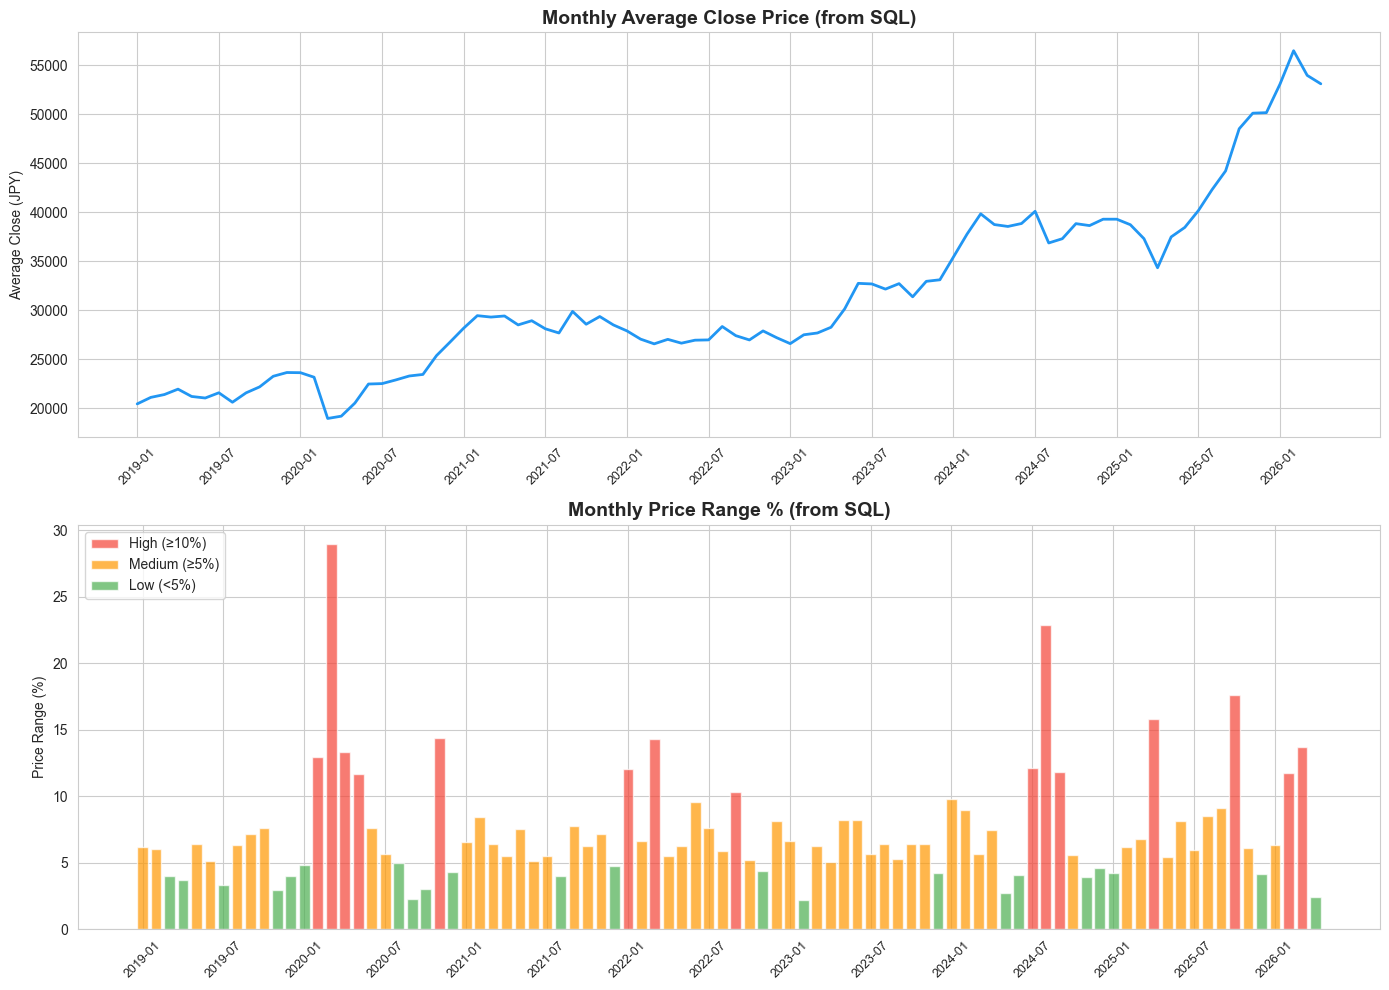

✓ SQL データによる月次分析グラフ保存完了


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (14, 6)
sns.set_style('whitegrid')

#SQLで月次データを取得
monthly_data = pd.read_sql("""
    SELECT
        month,
        avg_close,
        price_range_pct
    FROM processed_monthly
    ORDER BY month
""", conn)

#グラフ作成
fig, axes = plt.subplots(2, 1, figsize=(14,10))

#上段:月次平均株価の推移
axes[0].plot(range(len(monthly_data)), monthly_data['avg_close'],
            color='#2196F3', linewidth=2)
axes[0].set_title('Monthly Average Close Price (from SQL)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Average Close (JPY)')

# x軸ラベルを間引いて表示（6ヶ月おき）
tick_positions = range(0, len(monthly_data), 6)
tick_labels = [monthly_data['month'].iloc[i] for i in tick_positions]
axes[0].set_xticks(tick_positions)
axes[0].set_xticklabels(tick_labels, rotation=45, fontsize=9)

# 下段：月次ボラティリティ
colors = ['#F44336' if v >= 10 else '#FF9800' if v >= 5 else '#4CAF50' 
          for v in monthly_data['price_range_pct']]
axes[1].bar(range(len(monthly_data)), monthly_data['price_range_pct'], color=colors, alpha=0.7)
axes[1].set_title('Monthly Price Range % (from SQL)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Price Range (%)')
axes[1].set_xticks(tick_positions)
axes[1].set_xticklabels(tick_labels, rotation=45, fontsize=9)

#　凡例を手動で作成
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#F44336', alpha=0.7, label='High (≥10%)'),
    Patch(facecolor='#FF9800', alpha=0.7, label='Medium (≥5%)'),
    Patch(facecolor='#4CAF50', alpha=0.7, label='Low (<5%)')
]
axes[1].legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.savefig('sql_monthly_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ SQL データによる月次分析グラフ保存完了")

## 7.データベースの接続を閉じる
使い終わったらSQLを閉じる。ひらっきぱなしはデータ破損の元。

In [11]:
#最終確認:テーブル一覧
tables = pd.read_sql("""
    SELECT name, type
    FROM sqlite_master
    WHERE type='table'
    ORDER BY name
""", conn)
print("【データベース内のテーブル一覧】")
print(tables.to_string(index=False))

# 接続を閉じる
conn.close()
print("\n✓ データベース接続を閉じました")
print("✓ Notebook 4 完了")

【データベース内のテーブル一覧】
             name  type
processed_monthly table
    raw_nikkei225 table

✓ データベース接続を閉じました
✓ Notebook 4 完了
